# Experiment 1: SPICE Logistic Circuit — Bifurcation Diagram

Reproduce Fig.1: SPICE-simulated Logistic circuit bifurcation diagram.

Sweeps μ from 0.5 to 2.0, runs ngspice for each value, samples the circuit output.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess, tempfile, os
import sys
sys.path.insert(0, '..')
from spice_v2 import compute_cooling_params

In [2]:
def run_logistic_spice(mu, n_iter=500, f_clock=1e6):
    """Run one SPICE simulation at fixed mu, return trajectory."""
    t_clk = 1.0 / f_clock
    t_total = n_iter * t_clk
    t_step = t_clk / 20
    v_sat = 10.8
    mult_term = f'1.004*V(v_x)*V(v_x) + 0.05'
    
    netlist = f"""* Logistic bifurcation sweep
Rsrc v_out tl_in 50
T1 tl_in 0 tl_out 0 Z0=50 TD={t_clk:.12e}
Rload tl_out 0 50
Bbuf v_x 0 V = 2*V(tl_out)
Bsum v_sum 0 V = 1.0 - {mu} * ({mult_term})
Rop v_sum v_filt 160
Cop v_filt 0 1n
Bsat v_out 0 V = {v_sat}*tanh(V(v_filt)/{v_sat})
.ic V(v_out)=0.5 V(v_filt)=0.5 V(tl_in)=0.25 V(tl_out)=0.25
.tran {t_step:.12e} {t_total:.12e} uic
.control
run
wrdata /tmp/bif_out.txt v(v_out)
quit
.endc
.end
"""
    with open('/tmp/bif.cir', 'w') as f:
        f.write(netlist)
    subprocess.run(['ngspice', '-b', '/tmp/bif.cir'],
                   capture_output=True, text=True, timeout=60)
    data = np.loadtxt('/tmp/bif_out.txt')
    t_arr, v = data[:, 0], data[:, 1]
    traj = []
    for i in range(10, n_iter):
        idx = np.searchsorted(t_arr, (i + 0.5) * t_clk)
        if idx < len(v): traj.append(float(v[idx]))
    return np.array(traj)

In [3]:
# Sweep mu values
mu_values = np.linspace(0.5, 2.0, 100)
bif_mu, bif_x = [], []

for i, mu in enumerate(mu_values):
    traj = run_logistic_spice(mu, n_iter=500)
    pts = traj[-100:]  # attractor
    bif_mu.extend([mu] * len(pts))
    bif_x.extend(pts.tolist())
    if (i+1) % 20 == 0:
        print(f'{i+1}/{len(mu_values)} done')

print(f'Total points: {len(bif_x)}')

20/100 done
40/100 done
60/100 done
80/100 done
100/100 done
Total points: 10000


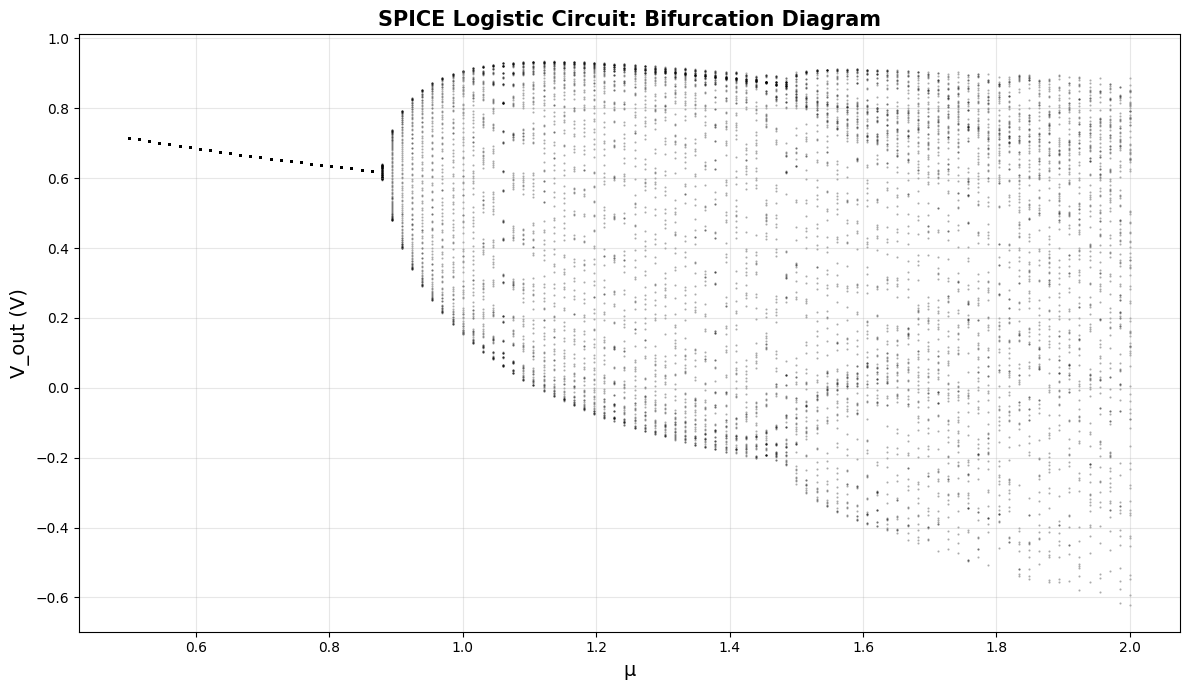

Saved fig1_bifurcation.png


In [7]:
# Plot bifurcation diagram
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(bif_mu, bif_x, s=0.3, c='black', alpha=0.3)
ax.set_xlabel('μ', fontsize=14)
ax.set_ylabel('V_out (V)', fontsize=14)
ax.set_title('SPICE Logistic Circuit: Bifurcation Diagram', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_bifurcation.png', dpi=200)
plt.show()
print('Saved fig1_bifurcation.png')